# Timeseries extraction

SHIVER provides easy access to timeseries of ice velocity through the data publishing utility **Source Cooperative**. 

To extract a timeseries, it makes sense to use the Zarr store optimized for timeseries extraction. By doing so, we will likely only need to load one chunk of velocity data (<100 MB). If your query location happens to land on a chunk boundary or several boundaries, we may need to load up to four chunks. Regardless, this operation will require a remarkably small amount of memory and file reads to generate a timeseries of ice velocity anywhere on Greenland or Antarctica.

The Greenland Zarr store suitable for this analysis is called `greenland_multisource_velocity_timeseries.zarr` whilst the Antarctic equivalent is called `antarctica_multisource_velocity_timeseries.zarr` and their equivalent URLs are:

In [1]:

# Greenland URL
greenland_url = "https://data.source.coop/uos-shiver/greenland/greenland_multisource_velocity_timeseries.zarr"

# Antarctica URL
antarctica_url = "https://data.source.coop/uos-shiver/antarctica/antarctica_multisource_velocity_timeseries.zarr"


In the following, we can treat these URLs exactly like we would treat a local path on our machine.

In order to interact with one or both of these Zarr stores, we first need to load `xarray`, which allows us to lazily load the Zarr metadata. We will also need `pandas` to help with smoothing and filtering the data. It can be helpful to also load `pyproj`, so that we can initiate our search with geographic coordinates.

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer

We can then prepare our coordinates. In this example, let's extract a timeseries of ice velocity from Saqqarliup Alangorliup, just south of Jakobshavn Isbrae in west Greenland. 

The Greenland Zarr stores are provided in `EPSG:3413`.

In [3]:
# Convert geographic coordinates (Lon/Lat) to EPSG:3413 (X/Y)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)
lon, lat = -50.1874, 68.8267
x_center, y_center = transformer.transform(lon, lat)

In the most simple, case, we could simply use a single set of coordinates and extract a timeseries from a single spatial cell in the Zarr store. However, it is almost always better to extract your timeseries from a small region.

To achieve that, we can buffer our centre coordinates by 500 metres, creating a 1 x 1 km extraction area.

In [4]:
# Create a 500m spatial buffer bounding box
buffer = 500
xmin, xmax = x_center - buffer, x_center + buffer
ymin, ymax = y_center - buffer, y_center + buffer

Now that the extraction locations has been prepared, load the Zarr store lazily.

In [5]:
# Load the timeseries-optimized Zarr store lazily
url = "https://data.source.coop/uos-shiver/greenland/greenland_multisource_velocity_timeseries.zarr"
ds = xr.open_zarr(greenland_url, consolidated=True).sortby('time')

# Handle Y-axis orientation for slicing
y_slice = slice(ymax, ymin) if ds.y[0] > ds.y[-1] else slice(ymin, ymax)

There are then many ways one could aggregate the data from their extraction area into a single timeseries. In this simple example, we will take the spatial median to reduce the effect of outliers. 

> Note: if your extraction location encompasses an area with large spatial gradients in ice motion, then this approach could introduce erroneous temporal changes in ice motion as changes in spatial coverage are aliased as changes in flow speed over time. 

In [6]:
# Extract data lazily and compute the spatial median
subset = ds.sel(x=slice(xmin, xmax), y=y_slice)

# Explicitly call .compute() here to trigger the S3 download and reduction
# Here, we only want to compute the 'speed' variable, but other variables (vx, vy and respective errors) are avaialble
spatial_median = subset['speed'].median(dim=['x', 'y']).compute()

C:\Users\gg1bjd\AppData\Local\anaconda3\envs\shiver_env\Lib\site-packages\dask\_task_spec.py:767: RuntimeWarning: All-NaN slice encountered
  return self.func(*new_argspec, **kwargs)


For plotting purposes, it can be helpful to display a smoothed version of the velocity data. Again, there are many ways to accomplish this. In this example, we will use a simple 24-day rolling mean.

We will then only visualise the data from 2016 onwards.

In [7]:
# Convert the in-memory array to a Pandas DataFrame
df = spatial_median.to_dataframe()
df = df.dropna(subset=['speed']).sort_index()

# Calculate a 24-day rolling mean
df['rolling_mean'] = df['speed'].rolling('24D').mean()

# Filter for plotting (2016 onwards)
df_plot = df[df.index >= '2016-01-01']

Finally, we can plot the results.

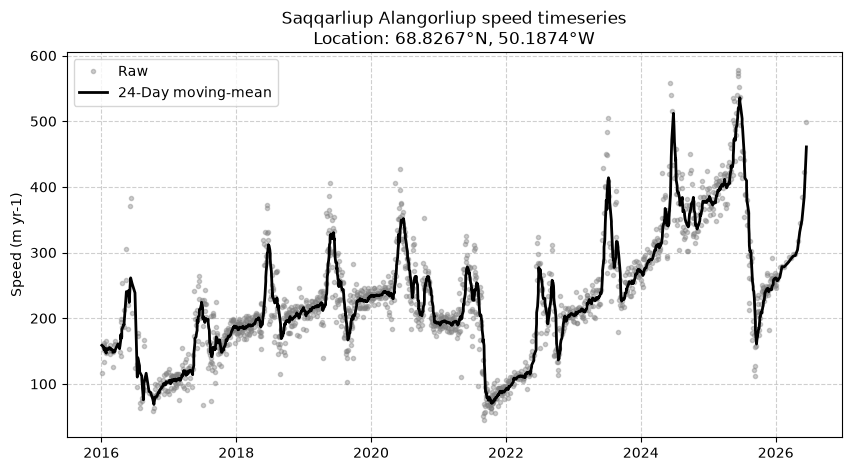

In [8]:
# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(
    df_plot.index, df_plot['speed'], 
    marker='o', color='grey', markersize=3, linestyle='', alpha=0.4, label='Raw '
)
plt.plot(
    df_plot.index, df_plot['rolling_mean'], 
    color='black', linewidth=2, label='24-Day moving-mean'
)

plt.title(f"Saqqarliup Alangorliup speed timeseries\nLocation: {lat}°N, {abs(lon)}°W")
plt.ylabel("Speed (m yr-1)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()